# 01. Pre-EDA, Cleaning & Pre-processing

Notebook này sử dụng dataset đã merge từ `products.csv` và `reviews.csv`.

Input:

`Dataset/raw/amazon_products_reviews_merged.csv`

Output:

`Dataset/processed/cleaned_amazon_dataset.csv`

Mục tiêu:

- Khảo sát sơ bộ dữ liệu sau merge.
- Kiểm tra missing values, duplicate, kiểu dữ liệu.
- Làm sạch dữ liệu cơ bản.
- Chuẩn hóa text.
- Lưu dataset sạch để phục vụ EDA chuyên sâu và Seller ESG Scoring.

## Import thư viện
Nạp các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

# Notebook đang nằm trong thư mục notebooks
ROOT_DIR = Path.cwd().parent

# Input: file đã merge từ products.csv và reviews.csv
INPUT_PATH = ROOT_DIR / "Dataset" / "raw" / "amazon_products_reviews_merged.csv"

# Output: file sau cleaning & preprocessing
OUTPUT_DIR = ROOT_DIR / "Dataset" / "processed"
OUTPUT_PATH = OUTPUT_DIR / "cleaned_amazon_dataset.csv"

print("Root dir:", ROOT_DIR)
print("Input path:", INPUT_PATH)
print("Output path:", OUTPUT_PATH)
print("Input exists:", INPUT_PATH.exists())

Root dir: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049
Input path: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049\Dataset\raw\amazon_products_reviews_merged.csv
Output path: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049\Dataset\processed\cleaned_amazon_dataset.csv
Input exists: True


## Load dataset

Đọc dataset đã merge từ thư mục `Dataset/raw`.

In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy file input: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6327, 28)


,asin,about_item,product_description,availability,brand_name,manufacturer,price_value,rating_count,rating_stars,recent_purchases,...,reviewmetadata,reviewtext,reviewtitle,verifiedpurchase,cleaned_review_text,sentiment_score,product_text,review_text_clean,has_review,has_product_info
0,B0DLGB4RYH,Material: Men's polo shirt is made of soft pol...,NaN,In Stock,COOFANDY Store,NaN,19.992,20 ratings,4.4 out of 5 stars,NaN,...,"Reviewed in the United States on March 6, 2025",‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,False,coofandy men polo shirt fantastic blend style ...,0.292024,Material: Men's polo shirt is made of soft pol...,coofandy men polo shirt fantastic blend style ...,True,True
1,B0DRXF62JH,"PERFORMANCE:These men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,NaN,29.995,5 ratings,4.6 out of 5 stars,NaN,...,"Reviewed in the United States on March 7, 2025",I love these. They look good. They fit well. T...,New favorite shirts,False,love look good fit well comfortable breathable...,0.560000,"PERFORMANCE:These men polo shirts are soft,lig...",love look good fit well comfortable breathable...,True,True
2,B0DRXF62JH,"PERFORMANCE:These men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,NaN,29.995,5 ratings,4.6 out of 5 stars,NaN,...,"Reviewed in the United States on February 27, ...",My expectations were low -- how good could shi...,Incredibly Good Deal,False,expectation low good could shirt sell one mist...,0.192321,"PERFORMANCE:These men polo shirts are soft,lig...",expectation low good could shirt sell one mist...,True,True
3,B0DRXF62JH,"PERFORMANCE:These men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,NaN,29.995,5 ratings,4.6 out of 5 stars,NaN,...,"Reviewed in the United States on February 26, ...",This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,False,pack multicolor shirt really brainer wear type...,0.307949,"PERFORMANCE:These men polo shirts are soft,lig...",pack multicolor shirt really brainer wear type...,True,True
4,B0DRXF62JH,"PERFORMANCE:These men polo shirts are soft,lig...",NaN,In Stock,ZITY Store,NaN,29.995,5 ratings,4.6 out of 5 stars,NaN,...,"Reviewed in the United States on February 20, ...",With these three polo shirts I was very satisf...,Pocket Polos Looks Good,False,three polo shirt satisfied quality material go...,0.250000,"PERFORMANCE:These men polo shirts are soft,lig...",three polo shirt satisfied quality material go...,True,True


## Dataset overview

Kiểm tra tổng quan dữ liệu:

- Số dòng, số cột.
- Danh sách cột.
- Kiểu dữ liệu.
- Số dòng duplicate toàn phần.

In [3]:
print("Shape:", df.shape)

print("\nDanh sách cột:")
print(df.columns.tolist())

print("\nThông tin kiểu dữ liệu:")
df.info()

print("\nSố dòng duplicate toàn phần:", df.duplicated().sum())

Shape: (6327, 28)

Danh sách cột:
['asin', 'about_item', 'product_description', 'availability', 'brand_name', 'manufacturer', 'price_value', 'rating_count', 'rating_stars', 'recent_purchases', 'seller_name', 'seller_page_url', 'rank_1', 'best_sellers_rank', 'productasin', 'productvariant', 'rating', 'reviewid', 'reviewmetadata', 'reviewtext', 'reviewtitle', 'verifiedpurchase', 'cleaned_review_text', 'sentiment_score', 'product_text', 'review_text_clean', 'has_review', 'has_product_info']

Thông tin kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6327 entries, 0 to 6326
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   asin                 6327 non-null   object 
 1   about_item           6327 non-null   object 
 2   product_description  2340 non-null   object 
 3   availability         6228 non-null   object 
 4   brand_name           6327 non-null   object 
 5   manufacturer        

## Missing values analysis

Tính số lượng và tỷ lệ missing values của từng cột.

Chỉ hiển thị top 20 cột có tỷ lệ thiếu cao nhất để dễ quan sát.

,missing_count,missing_rate_percent
product_description,3987,63.015647
manufacturer,3968,62.715347
seller_page_url,2652,41.915600
rank_1,1442,22.791212
best_sellers_rank,1349,21.321321
recent_purchases,1084,17.132922
productvariant,491,7.760392
seller_name,105,1.659554
price_value,105,1.659554
availability,99,1.564723


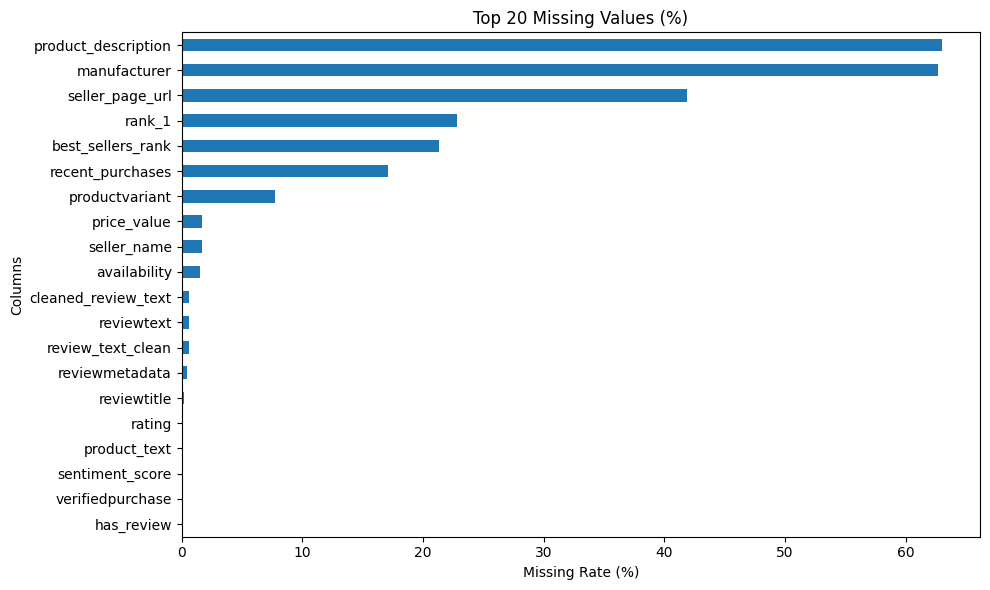

In [4]:
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate_percent": df.isna().mean() * 100
}).sort_values("missing_rate_percent", ascending=False)

display(missing_df.head(20))

plt.figure(figsize=(10, 6))
missing_df.head(20)["missing_rate_percent"].sort_values().plot(kind="barh")
plt.title("Top 20 Missing Values (%)")
plt.xlabel("Missing Rate (%)")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

## Key columns checking

Kiểm tra các cột quan trọng cho Seller ESG Scoring.

Các cột quan trọng gồm:

- `seller_name`: định danh seller.
- `productasin`, `asin`: định danh sản phẩm.
- `reviewid`: định danh review.
- `review_text_clean`: nội dung review sạch.
- `product_text`: nội dung sản phẩm.
- `sentiment_score`: điểm sentiment nếu đã có.

In [5]:
key_columns = [
    "seller_name",
    "productasin",
    "asin",
    "reviewid",
    "product_text",
    "review_text_clean",
    "rating",
    "sentiment_score",
    "verifiedpurchase",
    "price_value"
]

for col in key_columns:
    if col in df.columns:
        print(f"{col}: EXISTS | missing = {df[col].isna().sum()} | unique = {df[col].nunique()}")
    else:
        print(f"{col}: MISSING")

seller_name: EXISTS | missing = 105 | unique = 260
productasin: EXISTS | missing = 0 | unique = 700
asin: EXISTS | missing = 0 | unique = 700
reviewid: EXISTS | missing = 0 | unique = 6327
product_text: EXISTS | missing = 0 | unique = 688
review_text_clean: EXISTS | missing = 38 | unique = 6183
rating: EXISTS | missing = 7 | unique = 5
sentiment_score: EXISTS | missing = 0 | unique = 3054
verifiedpurchase: EXISTS | missing = 0 | unique = 2
price_value: EXISTS | missing = 105 | unique = 493


## Numerical columns analysis

Phân tích sơ bộ các biến số quan trọng:

- `price_value`
- `rating`
- `sentiment_score`
- `helpfulvote`

Các biến này có thể dùng cho phân tích chất lượng sản phẩm, phản hồi khách hàng và ESG scoring sau này.

Numerical columns found: ['price_value', 'rating', 'sentiment_score']


,price_value,rating,sentiment_score
count,6222.000000,6320.000000,6327.000000
mean,34.215317,4.533228,0.307545
std,23.134529,0.855710,0.218020
min,5.457300,1.000000,-1.000000
25%,19.990000,4.000000,0.168568
50%,28.792800,5.000000,0.300000
75%,41.391700,5.000000,0.450000
max,174.990000,5.000000,1.000000


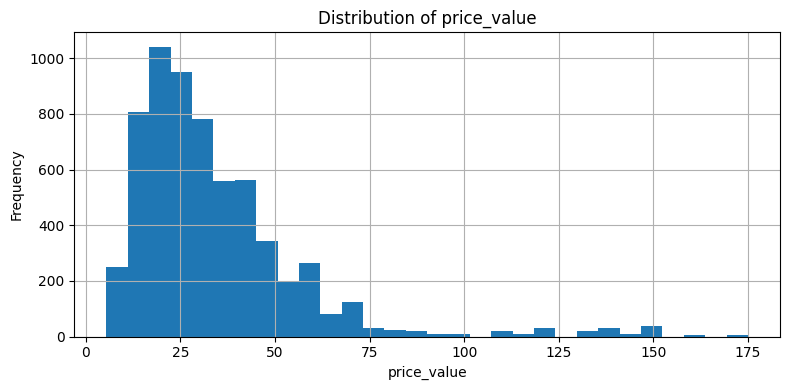

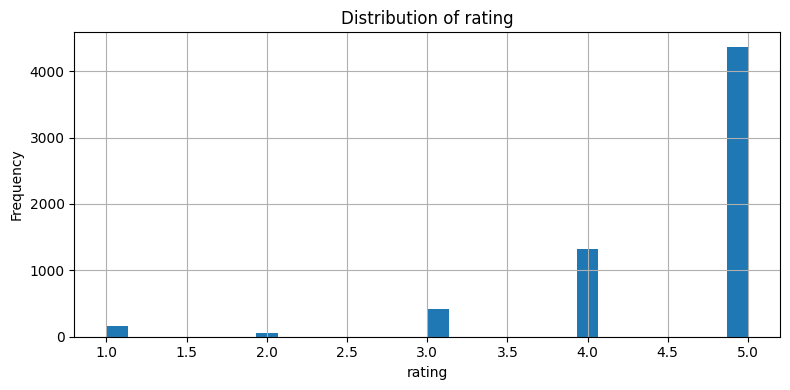

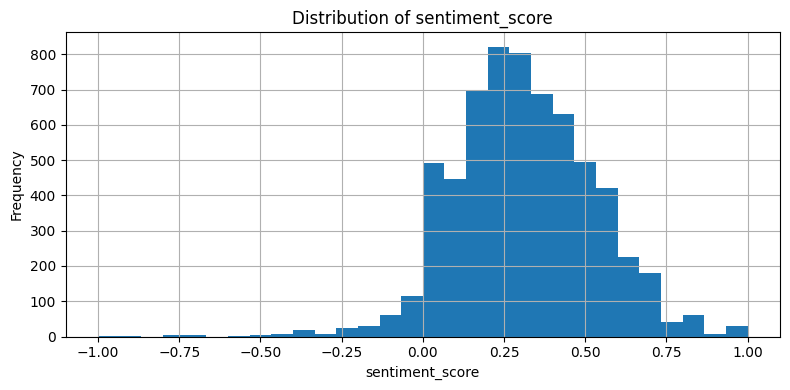

In [7]:
numerical_cols = [
    "price_value",
    "rating",
    "sentiment_score",
    "helpfulvote"
]

existing_num_cols = [col for col in numerical_cols if col in df.columns]

print("Numerical columns found:", existing_num_cols)

if existing_num_cols:
    display(df[existing_num_cols].describe())

    for col in existing_num_cols:
        plt.figure(figsize=(8, 4))
        df[col].dropna().hist(bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
else:
    print("Không có cột numerical phù hợp để phân tích.")

## Product and seller analysis

Phân tích sơ bộ thông tin sản phẩm và seller:

- Top brand xuất hiện nhiều nhất.
- Top seller xuất hiện nhiều nhất.
- Tình trạng availability.
- Phân phối giá sản phẩm.

Top 10 brands:


brand_name
Hanes Store                      318
Amazon Essentials Store          234
Under Armour Store               196
Lee Store                        176
adidas Store                     162
Skechers Store                   145
POLO RALPH LAUREN Store          141
Dokotoo Store                    136
COOFANDY Store                   132
Simple Joys by Carter's Store    112
Name: count, dtype: int64

Top 10 sellers:


seller_name
Amazon.com               2525
Dokotoo Flagship Shop     136
NaN                       105
PAATM SHIVA               105
COOFANDY                   72
SuperiorBrands             70
Automet-US                 65
Real Essentials            64
ZITY®                      61
PRETTYGARDEN               60
Name: count, dtype: int64

Availability distribution:


availability
In Stock                                       5721
Only 1 left in stock - order soon.              115
In stock                                        103
NaN                                              99
Only 3 left in stock - order soon.               94
Currently unavailable.                           77
Only 2 left in stock - order soon.               48
Only 5 left in stock - order soon.               22
Available to ship in 1-2 days                    20
This item will be released on May 20, 2025.      10
Name: count, dtype: int64

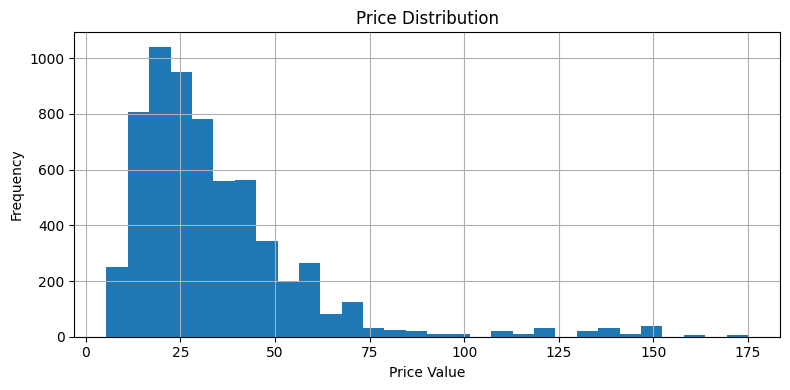

In [8]:
if "brand_name" in df.columns:
    print("Top 10 brands:")
    display(df["brand_name"].value_counts(dropna=False).head(10))

if "seller_name" in df.columns:
    print("Top 10 sellers:")
    display(df["seller_name"].value_counts(dropna=False).head(10))

if "availability" in df.columns:
    print("Availability distribution:")
    display(df["availability"].value_counts(dropna=False).head(10))

if "price_value" in df.columns:
    plt.figure(figsize=(8, 4))
    df["price_value"].dropna().hist(bins=30)
    plt.title("Price Distribution")
    plt.xlabel("Price Value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Review analysis

Phân tích sơ bộ dữ liệu review:

- Phân phối rating.
- Phân phối sentiment score.
- Tỷ lệ verified purchase.
- Độ dài review.

Không dùng `rating_stars` và `rating_count` làm phân tích chính vì các cột này thường có coverage thấp hoặc rỗng trong dataset Amazon hiện tại.

Rating distribution:


rating
1.0     158
2.0      55
3.0     414
4.0    1325
5.0    4368
NaN       7
Name: count, dtype: int64

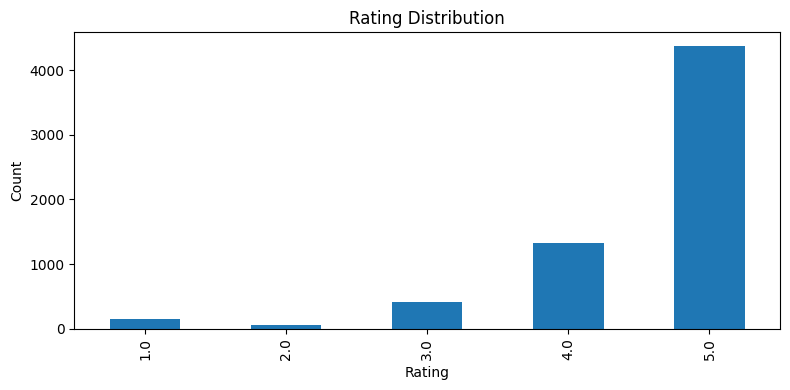

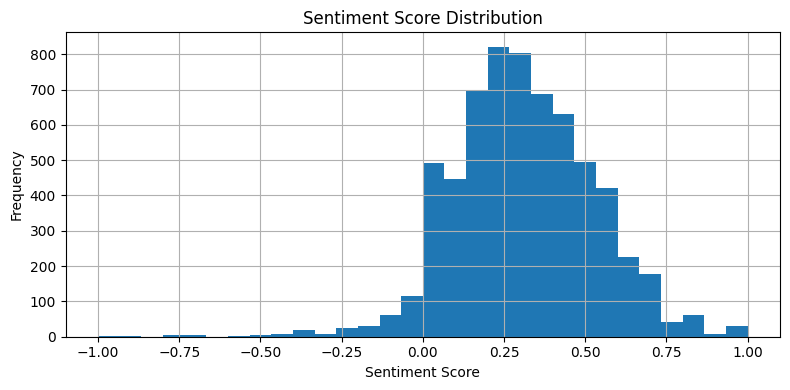

Verified purchase distribution:


verifiedpurchase
True     6167
False     160
Name: count, dtype: int64

Review length summary:


count    6327.000000
mean      206.760866
std       318.106358
min         0.000000
25%        54.000000
50%       113.000000
75%       231.500000
max      9498.000000
Name: review_length, dtype: float64

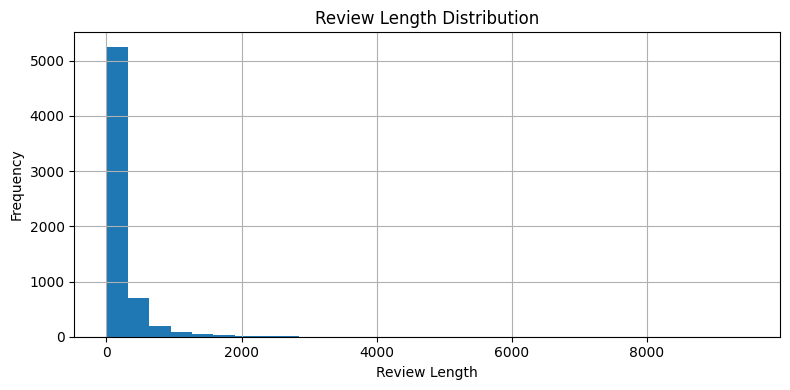

In [9]:
if "rating" in df.columns:
    print("Rating distribution:")
    display(df["rating"].value_counts(dropna=False).sort_index())

    plt.figure(figsize=(8, 4))
    df["rating"].dropna().value_counts().sort_index().plot(kind="bar")
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

if "sentiment_score" in df.columns:
    plt.figure(figsize=(8, 4))
    df["sentiment_score"].dropna().hist(bins=30)
    plt.title("Sentiment Score Distribution")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

if "verifiedpurchase" in df.columns:
    print("Verified purchase distribution:")
    display(df["verifiedpurchase"].value_counts(dropna=False))

text_source_col = None

if "review_text_clean" in df.columns:
    text_source_col = "review_text_clean"
elif "reviewtext" in df.columns:
    text_source_col = "reviewtext"

if text_source_col:
    df["review_length"] = df[text_source_col].fillna("").astype(str).str.len()

    print("Review length summary:")
    display(df["review_length"].describe())

    plt.figure(figsize=(8, 4))
    df["review_length"].hist(bins=30)
    plt.title("Review Length Distribution")
    plt.xlabel("Review Length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Create working copy for cleaning

Tạo bản sao `cleaned_df` để thực hiện cleaning.

Không chỉnh trực tiếp trên `df` nhằm giữ lại dữ liệu gốc sau merge để đối chiếu khi cần.

In [10]:
cleaned_df = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", cleaned_df.shape)

Original shape: (6327, 29)
Working copy shape: (6327, 29)


## Standardize column names

Chuẩn hóa tên cột một lần nữa để đảm bảo thống nhất:

- Xóa khoảng trắng đầu/cuối.
- Chuyển về chữ thường.
- Thay `/` bằng `_`.
- Thay khoảng trắng bằng `_`.

Việc này giúp tránh lỗi khi gọi tên cột trong các bước sau.

In [11]:
cleaned_df.columns = (
    cleaned_df.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

print("Columns after standardization:")
print(cleaned_df.columns.tolist())

Columns after standardization:
['asin', 'about_item', 'product_description', 'availability', 'brand_name', 'manufacturer', 'price_value', 'rating_count', 'rating_stars', 'recent_purchases', 'seller_name', 'seller_page_url', 'rank_1', 'best_sellers_rank', 'productasin', 'productvariant', 'rating', 'reviewid', 'reviewmetadata', 'reviewtext', 'reviewtitle', 'verifiedpurchase', 'cleaned_review_text', 'sentiment_score', 'product_text', 'review_text_clean', 'has_review', 'has_product_info', 'review_length']


## Remove duplicates

Xóa review bị trùng.

Ưu tiên dùng `reviewid` vì đây là mã định danh review rõ ràng nhất.

Nếu không có `reviewid`, dùng tổ hợp:

- `productasin`
- `reviewtext`
- `rating`

In [12]:
before_dedup = cleaned_df.shape[0]

if "reviewid" in cleaned_df.columns:
    cleaned_df = cleaned_df.drop_duplicates(subset=["reviewid"])
    print("Đã xóa duplicate theo reviewid.")
else:
    duplicate_keys = [col for col in ["productasin", "reviewtext", "rating"] if col in cleaned_df.columns]

    if duplicate_keys:
        cleaned_df = cleaned_df.drop_duplicates(subset=duplicate_keys)
        print(f"Đã xóa duplicate theo: {duplicate_keys}")
    else:
        cleaned_df = cleaned_df.drop_duplicates()
        print("Không có key phù hợp, đã xóa duplicate toàn dòng.")

after_dedup = cleaned_df.shape[0]

print("Rows before:", before_dedup)
print("Rows after :", after_dedup)
print("Removed    :", before_dedup - after_dedup)

Đã xóa duplicate theo reviewid.
Rows before: 6327
Rows after : 6327
Removed    : 0


## Normalize text fields

Làm sạch text cơ bản:

- Chuyển text về string.
- Chuyển về lowercase.
- Xóa HTML tag nếu có.
- Xóa URL nếu có.
- Xóa khoảng trắng thừa.

Các cột text chính:

- `product_text`
- `review_text_clean`
- `reviewtext`
- `reviewtitle`

In [13]:
def clean_text_basic(text):
    if pd.isna(text):
        return np.nan

    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

text_cols = [
    "product_text",
    "review_text_clean",
    "reviewtext",
    "reviewtitle",
    "about_item",
    "product_description"
]

existing_text_cols = [col for col in text_cols if col in cleaned_df.columns]

for col in existing_text_cols:
    cleaned_df[col] = cleaned_df[col].apply(clean_text_basic)

print("Text columns cleaned:", existing_text_cols)

Text columns cleaned: ['product_text', 'review_text_clean', 'reviewtext', 'reviewtitle', 'about_item', 'product_description']


## Handle missing values

Xử lý missing values ở mức cơ bản:

- Text: thay bằng chuỗi rỗng.
- Categorical: thay bằng `"unknown"`.
- Numerical: chuyển về numeric và fill bằng median.

Không xóa quá nhiều dòng vì dataset ESG cần giữ review và seller information để phân tích.

In [14]:
text_fill_cols = [
    "product_text",
    "review_text_clean",
    "reviewtext",
    "reviewtitle"
]

cat_fill_cols = [
    "brand_name",
    "seller_name",
    "availability",
    "manufacturer",
    "verifiedpurchase",
    "productvariant"
]

num_fill_cols = [
    "price_value",
    "rating",
    "sentiment_score",
    "helpfulvote",
    "rating_count",
    "rating_stars",
    "recent_purchases"
]

for col in text_fill_cols:
    if col in cleaned_df.columns:
        cleaned_df[col] = cleaned_df[col].fillna("")

for col in cat_fill_cols:
    if col in cleaned_df.columns:
        cleaned_df[col] = cleaned_df[col].fillna("unknown")

for col in num_fill_cols:
    if col in cleaned_df.columns:
        cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors="coerce")
        median_value = cleaned_df[col].median()

        if pd.isna(median_value):
            cleaned_df[col] = cleaned_df[col].fillna(0)
        else:
            cleaned_df[col] = cleaned_df[col].fillna(median_value)

print("Missing values handled.")

Missing values handled.


c:\Users\ASPIRE 7\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\ASPIRE 7\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\ASPIRE 7\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## Create helper features

Tạo thêm một số biến hỗ trợ cho EDA chuyên sâu và ESG scoring:

- `review_length`: độ dài review.
- `product_text_length`: độ dài text sản phẩm.
- `has_review`: có review hay không.
- `has_product_info`: có seller information hay không.
- `is_verified_purchase`: chuẩn hóa verified purchase về dạng boolean.

In [15]:
if "review_text_clean" in cleaned_df.columns:
    cleaned_df["review_length"] = cleaned_df["review_text_clean"].astype(str).str.len()
elif "reviewtext" in cleaned_df.columns:
    cleaned_df["review_length"] = cleaned_df["reviewtext"].astype(str).str.len()
else:
    cleaned_df["review_length"] = 0

if "product_text" in cleaned_df.columns:
    cleaned_df["product_text_length"] = cleaned_df["product_text"].astype(str).str.len()
else:
    cleaned_df["product_text_length"] = 0

if "review_text_clean" in cleaned_df.columns:
    cleaned_df["has_review"] = cleaned_df["review_text_clean"].astype(str).str.strip().ne("")
elif "reviewtext" in cleaned_df.columns:
    cleaned_df["has_review"] = cleaned_df["reviewtext"].astype(str).str.strip().ne("")
else:
    cleaned_df["has_review"] = False

if "seller_name" in cleaned_df.columns:
    cleaned_df["has_product_info"] = cleaned_df["seller_name"].astype(str).str.lower().ne("unknown")
else:
    cleaned_df["has_product_info"] = False

if "verifiedpurchase" in cleaned_df.columns:
    cleaned_df["is_verified_purchase"] = (
        cleaned_df["verifiedpurchase"]
        .astype(str)
        .str.lower()
        .str.strip()
        .isin(["true", "yes", "y", "1", "verified purchase"])
    )
else:
    cleaned_df["is_verified_purchase"] = False

display(cleaned_df[[
    "review_length",
    "product_text_length",
    "has_review",
    "has_product_info",
    "is_verified_purchase"
]].head())

,review_length,product_text_length,has_review,has_product_info,is_verified_purchase
0,1038,1229,True,True,False
1,146,630,True,True,False
2,582,630,True,True,False
3,297,630,True,True,False
4,205,630,True,True,False


## Final missing values check

Kiểm tra lại missing values sau cleaning.

Nếu vẫn còn missing, có thể là các cột ít quan trọng hoặc các cột không dùng trực tiếp cho mô hình ESG.

In [16]:
final_missing_df = pd.DataFrame({
    "missing_count": cleaned_df.isna().sum(),
    "missing_rate_percent": cleaned_df.isna().mean() * 100
}).sort_values("missing_rate_percent", ascending=False)

display(final_missing_df.head(20))

,missing_count,missing_rate_percent
product_description,3987,63.015647
seller_page_url,2652,41.915600
rank_1,1442,22.791212
best_sellers_rank,1349,21.321321
cleaned_review_text,39,0.616406
reviewmetadata,31,0.489964
asin,0,0.000000
reviewtitle,0,0.000000
verifiedpurchase,0,0.000000
product_text,0,0.000000


## Save cleaned dataset

Lưu dataset đã clean vào:

`Dataset/processed/cleaned_amazon_dataset.csv`

Dataset này sẽ được dùng cho:

- EDA chuyên sâu.
- ESG indicator operationalization.
- Seller ESG Scoring.

In [17]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cleaned_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved cleaned dataset:", OUTPUT_PATH)
print("Final shape:", cleaned_df.shape)

print("\nFinal summary:")
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

if "seller_name" in cleaned_df.columns:
    print("Unique sellers:", cleaned_df["seller_name"].nunique())

if "asin" in cleaned_df.columns:
    print("Unique ASIN:", cleaned_df["asin"].nunique())

if "productasin" in cleaned_df.columns:
    print("Unique productASIN:", cleaned_df["productasin"].nunique())

if "has_review" in cleaned_df.columns:
    print(f"Has review rate: {cleaned_df['has_review'].mean():.2%}")

if "has_product_info" in cleaned_df.columns:
    print(f"Has product info rate: {cleaned_df['has_product_info'].mean():.2%}")

Saved cleaned dataset: c:\Users\ASPIRE 7\OneDrive\Tài liệu\UEH\CTD2026_DT049\Dataset\processed\cleaned_amazon_dataset.csv
Final shape: (6327, 31)

Final summary:
Rows: 6327
Columns: 31
Unique sellers: 261
Unique ASIN: 700
Unique productASIN: 700
Has review rate: 99.40%
Has product info rate: 98.34%
